# Neural ODE / Continoues Normalizing Flow based Galaxy-images Generator

In [1]:
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, TensorDataset
from torchinfo import summary
from torchdiffeq import odeint_adjoint, odeint
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
from umap import UMAP
import re
import h5py

# if nvidia gpu available use it
device = "cuda" if torch.cuda.is_available() else "cpu"

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("Nb of Devices: ", torch.cuda.device_count())
    print("Device:",[torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())])
    print("Compute capability:", torch.cuda.get_device_capability(0))
    print("Supported archs:", torch.cuda.get_arch_list())

2026-06-26 22:04:36.939231: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782511477.119016      34 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782511477.171540      34 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782511477.605181      34 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782511477.605218      34 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782511477.605221      34 computation_placer.cc:177] computation placer alr

PyTorch: 2.10.0+cu128
CUDA available: True
CUDA version: 12.8
Nb of Devices:  2
Device: ['Tesla T4', 'Tesla T4']
Compute capability: (7, 5)
Supported archs: ['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']


## 1. Dataset Preperation

In [2]:
# Load Data
data_path_64 = "/kaggle/input/datasets/mikematician/galaxy/Galaxy10_DECals_64.h5"

with h5py.File(data_path_64, "r") as f:
    images = np.array(f["images"])   # shape (17736, 64, 64, 3)
    labels = np.array(f["ans"])      # shape (17736,)

# Print Shapes
print("Images shape:", images.shape)
print("Labels shape:", labels.shape, "dtype:", labels.dtype)

Images shape: (17736, 64, 64, 3)
Labels shape: (17736,) dtype: uint8


In [3]:
# Class names from the Galaxy10 DECaLS documentation
class_names = {
    0: "Disturbed Galaxies",
    1: "Merging Galaxies",
    2: "Round Smooth Galaxies",
    3: "In-between Round Smooth Galaxies",
    4: "Cigar Shaped Smooth Galaxies",  
    5: "Barred Spiral Galaxies",
    6: "Unbarred Tight Spiral Galaxies",
    7: "Unbarred Loose Spiral Galaxies",
    8: "Edge-on Galaxies without Bulge",
    9: "Edge-on Galaxies with Bulge"
}

unique, counts = np.unique(labels, return_counts=True)
print("Class distribution:")
for u, c in zip(unique, counts):
    print(f"Class {u} ({class_names[u]}): {c}")

Class distribution:
Class 0 (Disturbed Galaxies): 1081
Class 1 (Merging Galaxies): 1853
Class 2 (Round Smooth Galaxies): 2645
Class 3 (In-between Round Smooth Galaxies): 2027
Class 4 (Cigar Shaped Smooth Galaxies): 334
Class 5 (Barred Spiral Galaxies): 2043
Class 6 (Unbarred Tight Spiral Galaxies): 1829
Class 7 (Unbarred Loose Spiral Galaxies): 2628
Class 8 (Edge-on Galaxies without Bulge): 1423
Class 9 (Edge-on Galaxies with Bulge): 1873


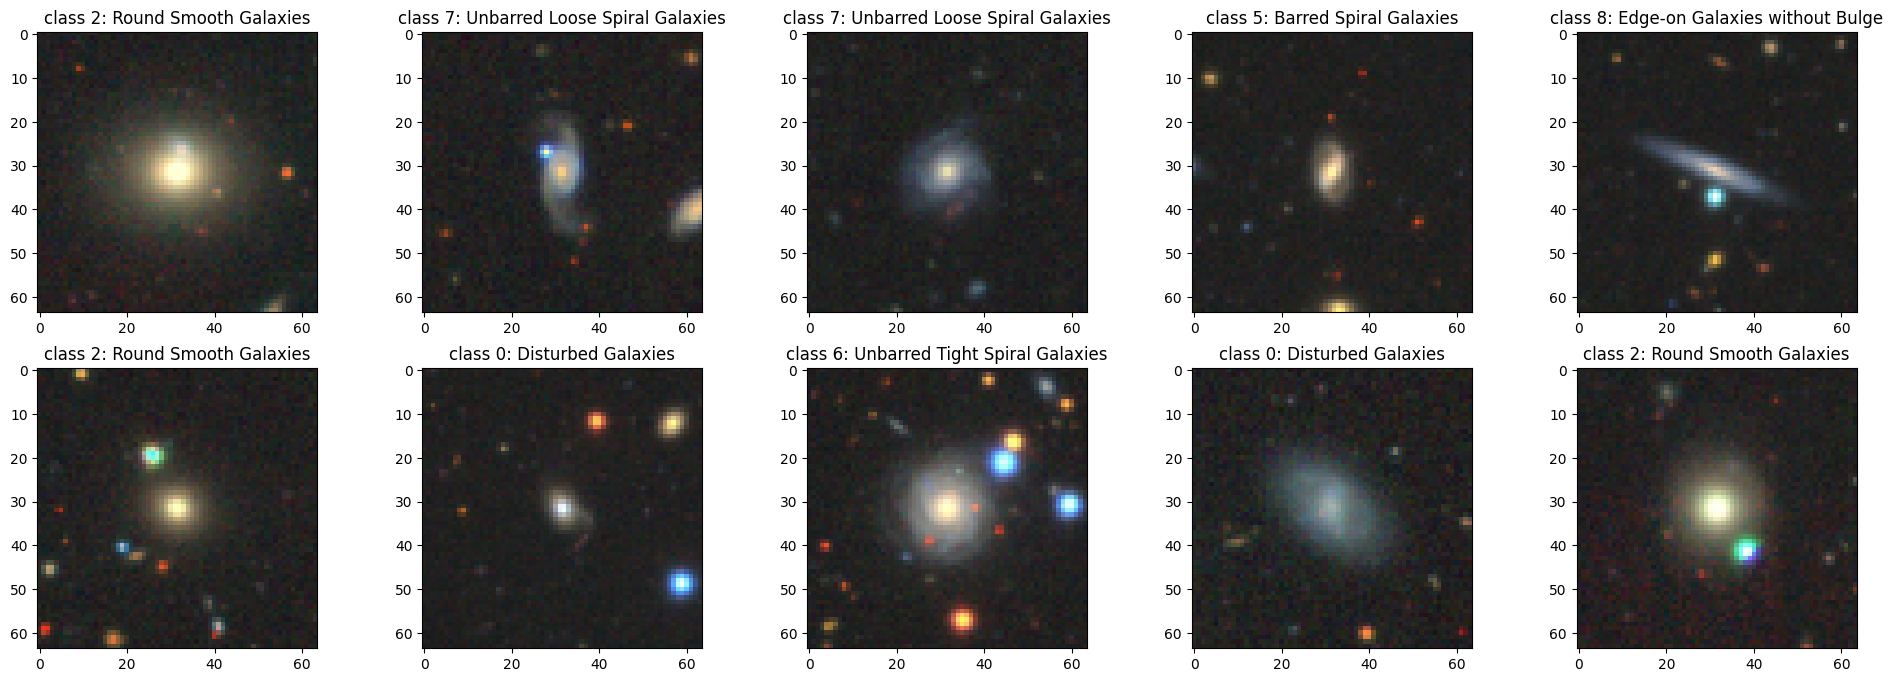

In [4]:
# Plot some Images
f, plane = plt.subplots(2, 5, figsize=(24, 8))
for row in plane:
    for axis in row:
        random_index = np.random.randint(0, len(labels))
        axis.imshow(images[random_index])
        axis.set_title(f"class {labels[random_index]}: {class_names[labels[random_index]]}")
plt.show()

In [5]:
# Normalize Pixel Values
images = (images / 255) * 2 -1

# numpy to torch
images = torch.from_numpy(images.astype(np.float32))
labels = torch.from_numpy(labels.astype(np.int64))

# BHWC to BCHW
images = images.permute(0, 3, 1, 2)

print(type(images), type(labels))

# Convert into Dataset
dataset = TensorDataset(images, labels)

print()
print(dataset)
print()
print("shape images: ", dataset.tensors[0].shape)
print("shape labels: ", dataset.tensors[1].shape)



<class 'torch.Tensor'> <class 'torch.Tensor'>


shape images:  torch.Size([17736, 3, 64, 64])
shape labels:  torch.Size([17736])


In [6]:
# reduce multidimensional data distribution onto 2D plain with UMAP
reducer = UMAP(n_neighbors=60, n_components=2, min_dist=0.4, metric="euclidean")

# fit reducer onto data
X = images.reshape(len(dataset), -1)
reducer.fit(X)

# make embedding
embedding_dataset = reducer.transform(X).T

(2, 17736)


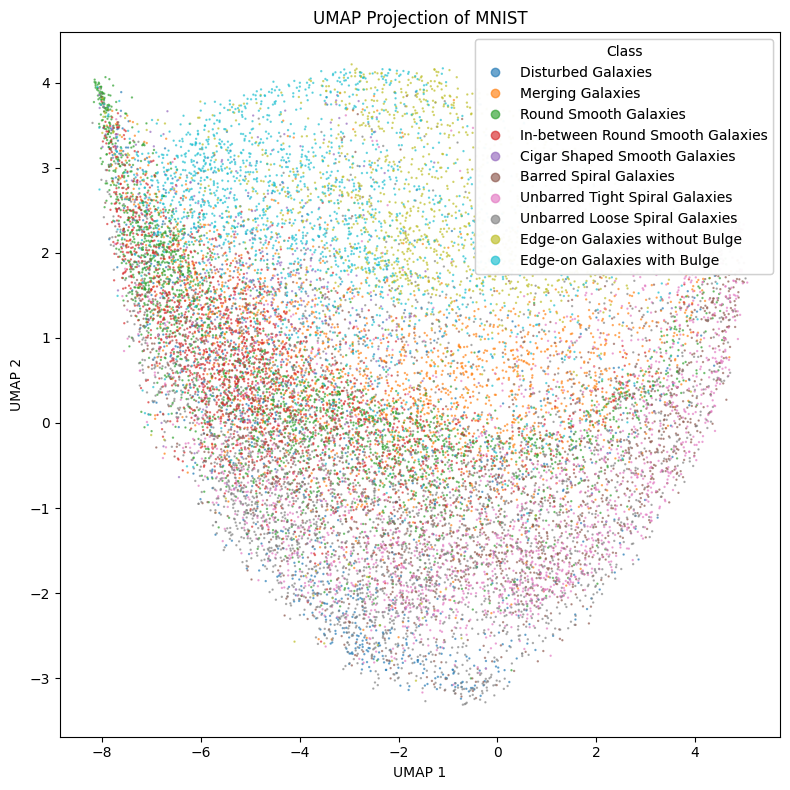

In [7]:
# plot embedding
print(embedding_dataset.shape)

fig, ax = plt.subplots(figsize=(8, 8))
scatter = ax.scatter(embedding_dataset[0], embedding_dataset[1], s=0.5, alpha=0.6, c=labels, cmap="tab10")
handles, label = scatter.legend_elements()
new_labels = [class_names[int(re.search(r'\d+', l).group())] for l in label]
legend = ax.legend(handles, new_labels, title="Class", loc="best")
ax.add_artist(legend)

ax.set_title("UMAP Projection of MNIST")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
plt.tight_layout()
plt.show()

## 2. Model Initialization

In [8]:
class SingleFlow(nn.Module):
    def __init__(self, input_channel):
        super().__init__()
        # Flow layers
        self.conv1 = nn.Conv2d(in_channels=input_channel+1, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(in_channels=64+1, out_channels=2*64, kernel_size=3, stride=2, padding=1)
        self.conv3 = nn.Conv2d(in_channels=2*64+1, out_channels=2*128, kernel_size=3, stride=1, padding=1)
        self.conv4 = nn.Conv2d(in_channels=2*128+1, out_channels=2*128, kernel_size=3, stride=2, padding=1)
        self.transconv1 = nn.ConvTranspose2d(in_channels=2*128+1, out_channels=2*128, kernel_size=3, stride=1, padding=1)
        self.transconv2 = nn.ConvTranspose2d(in_channels=2*128+1, out_channels=2*64, kernel_size=4, stride=2, padding=1)
        self.transconv3 = nn.ConvTranspose2d(in_channels=2*64+2*128+1, out_channels=2*64, kernel_size=3, stride=1, padding=1)
        self.transconv4 = nn.ConvTranspose2d(in_channels=2*64+1, out_channels=64, kernel_size=4, stride=2, padding=1)
        self.out_conv = nn.Conv2d(in_channels=64+64+1, out_channels=input_channel, kernel_size=3, stride=1, padding=1)
        self.norm1 = nn.GroupNorm(num_channels=2*64, num_groups=32)
        self.norm2 = nn.GroupNorm(num_channels=2*128, num_groups=32)
        self.norm3 = nn.GroupNorm(num_channels=2*128, num_groups=32)
        self.norm4 = nn.GroupNorm(num_channels=2*64, num_groups=32)
        self.norm5 = nn.GroupNorm(num_channels=2*64, num_groups=32)
        self.norm6 = nn.GroupNorm(num_channels=64, num_groups=32)
        self.activation = nn.SiLU()

    def _tc(self, y, t):
        # concatenate t as extra channel
        return torch.cat([y, t.view(-1,1,1,1).expand(y.shape[0],1,y.shape[2],y.shape[3])], dim=1)

    def forward(self, t, y):
        # CNN
        # encoder
        e1 = self.activation(self.conv1(self._tc(y,  t)))
        h  = self.activation(self.norm1(self.conv2(self._tc(e1, t))))
        e3 = self.activation(self.conv3(self._tc(h,  t)))   
        h  = self.activation(self.norm2(self.conv4(self._tc(e3, t))))
        # decoder
        h  = self.activation(self.norm3(self.transconv1(self._tc(h, t))))
        h  = self.activation(self.norm4(self.transconv2(self._tc(h, t))))
        h  = torch.cat([h, e3], dim=1)      
        h  = self.activation(self.norm5(self.transconv3(self._tc(h, t))))  
        h  = self.activation(self.norm6(self.transconv4(self._tc(h, t))))  
        h  = torch.cat([h, e1], dim=1) 
        h  = self.out_conv(self._tc(h, t))  
        return h
    

class CNF(nn.Module):
    def __init__(self, channels=3):
        super().__init__()
        self.channels=channels

        # U-Net
        self.flow1 = SingleFlow(self.channels)
        #self.flow2 = SingleFlow(self.channels)


    def forward(self, t, x_t):             
        y = x_t
        dy_dt = self.flow1(t, y)
        #dy_dt = self.flow2(t, dy_dt)

        return dy_dt


## 3. Model Training and Evaluation

### 3.1 Training

In [9]:
# Train step
def make_train_step(model, optimizer, grad_clipping, device):

    # training function that gets created
    def CFM_step(x_1, sigma_min=0.001, verbose=False):
        optimizer.zero_grad()
        model.train()

        # sample normal and uniform
        batch_size = x_1.shape[0]
        x_0 = torch.randn_like(x_1) 
        t = torch.rand((batch_size, 1, 1, 1), device=device)

        # Model eval
        x_t = ((1-(1-sigma_min)*t)*x_0 + t*x_1).float()
        model_eval = model(t, x_t)
        
        ## CFM loss
        flow = x_1 - (1-sigma_min)*x_0
        loss = torch.mean((model_eval - flow) ** 2) 
        
        # calculate gradient
        loss.backward()
        
        # verbose while training
        if verbose and (i%50==0 or i==1):
            print(f"=== Total Loss (batch: {i}) ===")
            print(f"{loss.mean().item():.7f}")
            print()
        
        # gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clipping)

        # optimization and scheduler
        optimizer.step()

        return loss.item()
    
    return CFM_step

In [10]:
# training parameters
epochs = 50
lr = 1e-4
batch_size = 256
gradient_clip = 100
weight_decay = 1e-6
sigma_min = 1e-6

# init model
model = CNF().to(device)

# define an optimizer
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

# define lr scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.7)

# Turn Datasets into Dataloader
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# create training function
training_step = make_train_step(model, optimizer, gradient_clip, device=device)

In [11]:
# Training Loop
train_history = []
for e in range(epochs):
    print(f"\n=============== Epoch: {e+1} ================")
    
    batch_loss = []
    batch_nfe = []
    for i, (image_batch, _) in enumerate(train_loader, 1):
        image_batch = image_batch.to(device)

        # verbose nur bei bestimmten Epochen
        verbose = (e+1) % 5 == 0 or e+1 == 1

        # perform a train step
        loss_b = training_step(image_batch, sigma_min, verbose=verbose)
        batch_loss.append(loss_b)

        if i % 10 == 0:
            with open("train_history.txt", "a") as f:
                f.write(f"batch: {i}, loss: {loss_b:.7f}\n")
    
    # calculate loss per epoch
    loss_e = np.array(batch_loss).mean()

    with open("train_history.txt", "a") as f:
        f.write(f"epoch: {e+1}\n")
        f.write(f"epoch loss: {loss_e:.7f}\n")
        f.write(f"Learning Rate: {optimizer.param_groups[0]['lr']:.2e}\n")

    # learning rate scheduler
    scheduler.step(loss_e)
    
    # training statistics
    train_history.append(loss_e)
    print(f"Loss: {loss_e:.7f}, Learning Rate: {optimizer.param_groups[0]['lr']:.2e}")

    # Model Checkpoint
    if (e+1) % 5 == 0:
        torch.save(model.state_dict(), f"flowmatching_checkpoint_epoch{e+1}.pt")
        print(f"Checkpoint saved (epoch {e+1})")


=============== Epoch: 1 ================
=== Total Loss (batch: 1) ===
1.6533585

=== Total Loss (batch: 50) ===
0.5100427

Loss: 0.7459196, Learning Rate: 1.00e-04

=============== Epoch: 2 ================
Loss: 0.2409868, Learning Rate: 1.00e-04

=============== Epoch: 3 ================
Loss: 0.1807864, Learning Rate: 1.00e-04

=============== Epoch: 4 ================
Loss: 0.1591412, Learning Rate: 1.00e-04

=============== Epoch: 5 ================
=== Total Loss (batch: 1) ===
0.1394901

=== Total Loss (batch: 50) ===
0.1425376

Loss: 0.1468190, Learning Rate: 1.00e-04
Checkpoint saved (epoch 5)

=============== Epoch: 6 ================
Loss: 0.1390250, Learning Rate: 1.00e-04

=============== Epoch: 7 ================
Loss: 0.1300589, Learning Rate: 1.00e-04

=============== Epoch: 8 ================
Loss: 0.1252225, Learning Rate: 1.00e-04

=============== Epoch: 9 ================
Loss: 0.1237878, Learning Rate: 1.00e-04

=============== Epoch: 10 ================
=== Tot

### 3.2 Evaluation

In [12]:
def load_train_history(filepath):
    train_history = []
    with open(filepath, "r") as f:
        content = f.read()
    
    parts = content.split("epoch loss:")
    for part in parts[1:]:
        loss = float(part.split()[0])        
        train_history.append(loss)
    
    return train_history

In [13]:
# load model and train history
#model.load_state_dict(torch.load("/kaggle/input/models/mikematician/regression-1-1/pytorch/default/1/flowmatching_checkpoint_epoch100.pt", map_location=device))
#train_history = load_train_history("/kaggle/input/models/mikematician/regression-1-1/pytorch/default/1/train_history.txt")

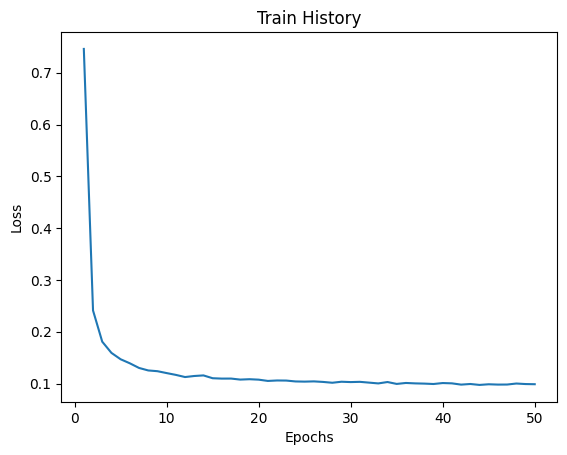

In [14]:
# Train Loss
plt.figure()
plt.plot(range(1, len(train_history)+1), train_history)
plt.title("Train History")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.show()

## 4. Generated Images

In [15]:
# Sample Function
@torch.no_grad()
def sample(model, num_samples, t_0, t_end, ode_solver, device, rtol, atol, shape=(3, 64, 64)):
    model.eval()
    y_0 = torch.randn(num_samples, *shape, device=device)
    y = odeint(model, y_0, torch.tensor([t_0, t_end], dtype=torch.float32, device=device), rtol=rtol, atol=atol, method=ode_solver)
    y_0, y_1 = y[:,...]
    
    return y_1, y_0

In [16]:
nb_samples = 100
t_0 = 0
t_1 = 1
ode_solver = "dopri5"
atol = 1e-7
rtol = 1e-7

generated_images , gaussian_noise = sample(model, nb_samples, t_0, t_1, ode_solver, device, rtol=rtol, atol=atol)

print(generated_images.shape)

torch.Size([100, 3, 64, 64])


In [17]:
# convert to cpu
generated_images_cpu = generated_images.cpu()
gaussian_noise_cpu = gaussian_noise.cpu()

In [18]:
# change dimensions for imshow
plot_gen   = ((generated_images_cpu + 1.0) / 2.0).clamp(0, 1).permute(0, 2, 3, 1)
plot_noise = gaussian_noise_cpu.permute(0, 2, 3, 1)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.0102396..3.6374245].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.8021815..3.9046848].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.413288..4.2768025].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.2094064..3.9305537].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.1315584..4.189278].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.7302134..3.564217].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.6634126..

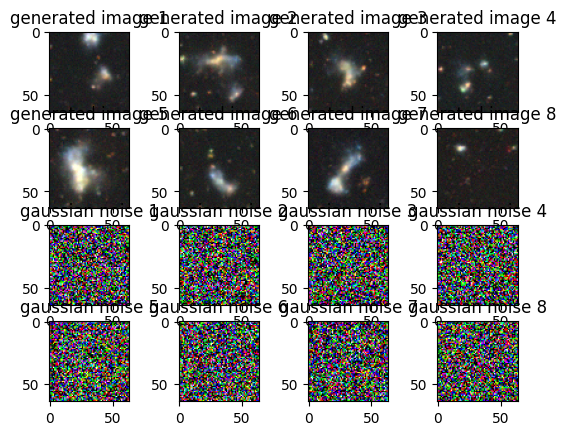

In [19]:
# plot example images
nb_plots = 8

fig, ax = plt.subplots(4, nb_plots//2)
ax = ax.flatten()
for i in range(0, nb_plots):
    random_nb = np.random.randint(nb_samples)
    ax[i].imshow(plot_gen[random_nb].squeeze())
    ax[i].set_title(f"generated image {i+1}")
    ax[i+nb_plots].imshow(plot_noise[random_nb].squeeze())
    ax[i+nb_plots].set_title(f"gaussian noise {i+1}")


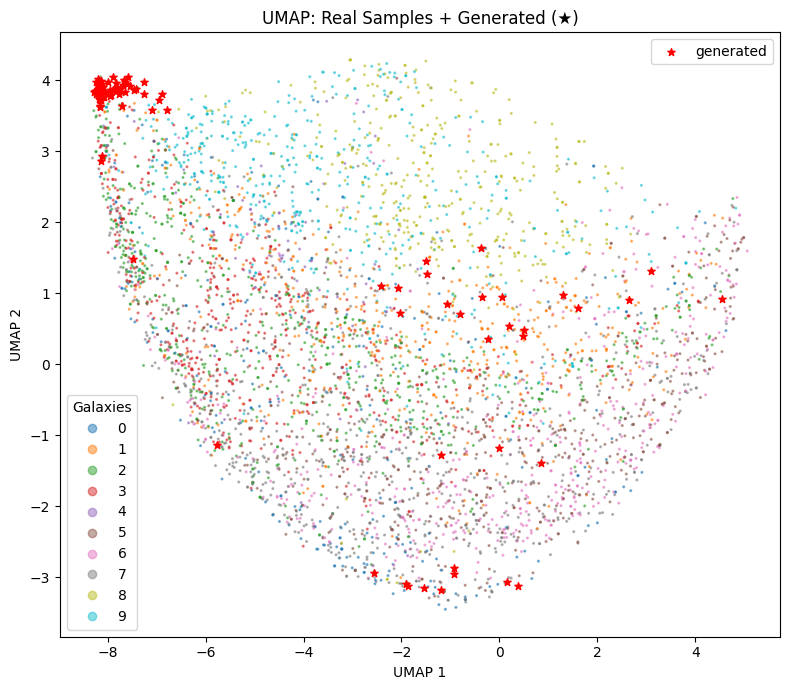

In [20]:
# Umap exploration
# nb of real samples
n_real = 5000

# real flat samples
random_X_real = []
random_L_real = []
random_nb = np.random.randint(labels.shape[0], size=(n_real))
for i in random_nb:
    random_X_real.append(images[i].numpy().astype("float32"))
    random_L_real.append(labels[i].numpy())
random_X_real = np.array(random_X_real).reshape(n_real, -1)
random_L_real = np.array(random_L_real)

# faltten generated data
X_gen = generated_images_cpu.reshape(len(generated_images_cpu), -1).numpy()

# project into learned umap projection
emb_real = reducer.transform(random_X_real).T
emb_gen  = reducer.transform(X_gen).T  

# plot
fig, ax = plt.subplots(1, 1, figsize=(8, 7))

# all data
sc = ax.scatter(emb_real[0], emb_real[1], c=random_L_real, cmap="tab10", s=1.5, alpha=0.5)
legend = ax.legend(*sc.legend_elements(), title="Galaxies", loc="best", markerscale=1)
ax.add_artist(legend)
ax.scatter(emb_gen[0], emb_gen[1], color="red", s=30, zorder=5, marker="*", label="generated")
ax.legend(loc="upper right")
ax.set_title("UMAP: Real Samples + Generated (★)")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")

plt.tight_layout()
plt.show()

In [21]:
print("gen std over all samples (per pixel, mean):", X_gen.std(axis=0).mean())
print("real std:", random_X_real.std(axis=0).mean())
print("sample[0] == sample[1]?", np.allclose(X_gen[0], X_gen[1]))

print("real  min/max/mean/std:", random_X_real.min(), random_X_real.max(), random_X_real.mean(), random_X_real.std())
print("gen   min/max/mean/std:", X_gen.min(),  X_gen.max(),  X_gen.mean(),  X_gen.std())

gen std over all samples (per pixel, mean): 0.16457315
real std: 0.14198609
sample[0] == sample[1]? False
real  min/max/mean/std: -1.0 1.0 -0.6733912 0.21688949
gen   min/max/mean/std: -1.1049656 2.0631897 -0.68374264 0.19967677
